## Calculate drift and render

1. Load data.  
2. Render
3. Find and crop an isolated fiducial
4. Plot x and y position of fudicial
5. Calculate drift for each iter.
6. Correct drift. 

In [57]:
import os
import decode
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

frames_per_iter = 250

out_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2'
h5s_path = os.path.join(out_path, f'processed-2025-06-27')

fig_path = os.path.join(out_path, 'figures-2025-07-16')

load_h5 = True

In [58]:
if load_h5:
    start_iter = 0 
    end_iter = 1069
    out_h5 = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}.h5')
    print(out_h5)
    emitters = decode.EmitterSet.load(out_h5)
    print(emitters)
else:
    start_iter = 200
    end_iter = 800
    # create empty emitter set for loading
    emitters = None
    for i in tqdm(range(start_iter, end_iter), desc="Loading iterations"):
        #print(os.path.join(h5s_path, f'iter_{i}.h5'))
        out_h5 = os.path.join(h5s_path, f'iter_{i}.h5')
        #print(i, start_iter, end_iter)
        if emitters is None:
            emitters = decode.EmitterSet.load(out_h5)
            #emitters.frame_ix += i * frames_per_iter
        else:
            #try:
            emitters_ = decode.EmitterSet.load(out_h5)
            #emitters_.frame_ix += i * frames_per_iter
            emitters = decode.EmitterSet.cat([emitters, emitters_])

D:\Janelia_slm_data\processed\Janelia PALM RUN2\emitters_0_1069.h5


MemoryError: Unable to allocate 3.02 GiB for an array with shape (270211344, 3) and data type float32

C:\Users\bnort\AppData\Local\Temp\ipykernel_35616\943530012.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_35616\943530012.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_

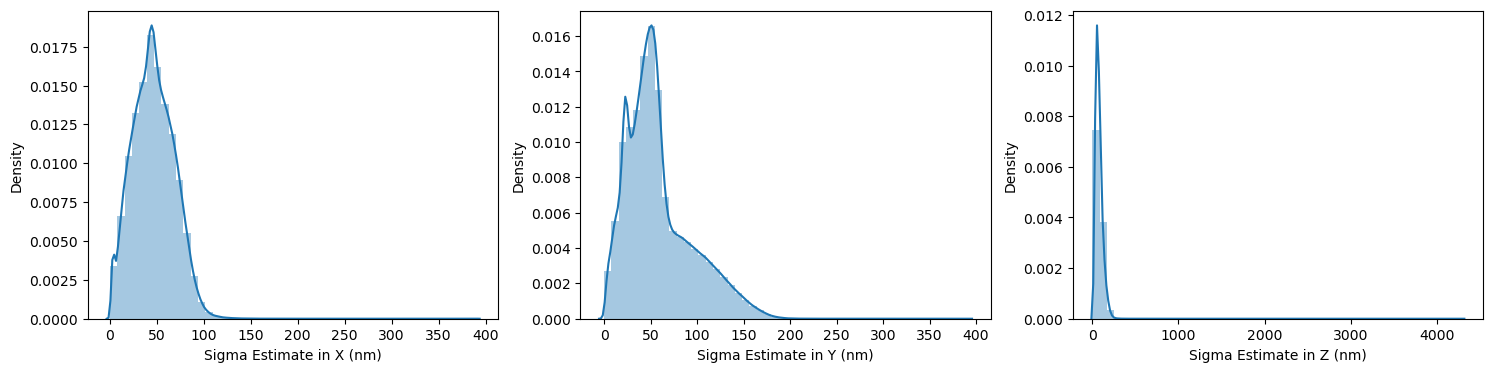

In [52]:
sub_sample = 100 

plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')

plt.show()

C:\Users\bnort\AppData\Local\Temp\ipykernel_35616\3137299338.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_px[::sub_sample,0].numpy())


Text(0.5, 0, 'Sigma Estimate in X (nm)')

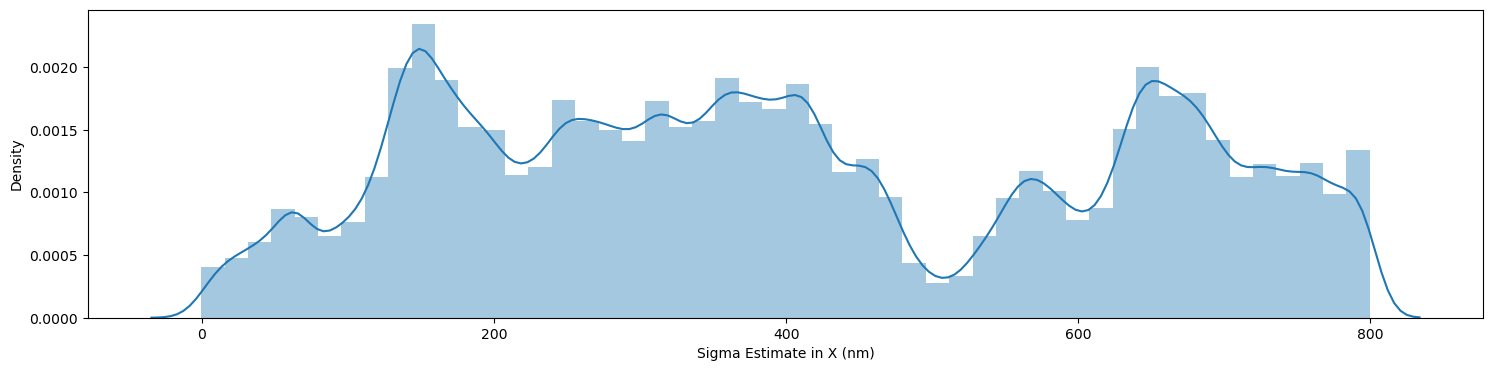

In [53]:
sub_sample = 100 

plt.figure(figsize=(18,4))
sns.distplot(emitters.xyz_px[::sub_sample,0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')



In [54]:
print(emitters)
sigma_x_high_threshold = 30 
sigma_y_high_threshold = 30
sigma_z_high_threshold = 60
prob_threshold = 0.8
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    
    ]

print(emitters_filtered)




EmitterSet
::num emitters: 270211344
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 267249
::spanned volume: [-5.9900337e-01 -7.0383626e-01 -1.3020839e+03] - [ 799.6174   799.60876 1261.7509 ]
0,1 0 500
EmitterSet
::num emitters: 18826910
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 267249
::spanned volume: [-5.4623306e-01 -6.6120219e-01 -1.3020839e+03] - [ 799.5229  798.9943 1214.7802]


In [55]:
def render_emitters(emitters):

    fig, axs = plt.subplots(2, 1, figsize=(24, 24))

    px_size = 10
    
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-1200, 1200], colextent=[-1200, 1200], plot_axis=(0, 1),
                            contrast=15.25).render(emitters, emitters.xyz_nm[:, 2], ax=axs[0])

    
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], plot_axis=(0, 2)).render(emitters, ax=axs[1])
    '''
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                            contrast=1.25).render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
        render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[1, 1])
    '''
    #plt.savefig(os.path.join(fig_path, rf'fitting\rendered.png'), dpi=300, bbox_inches='tight')
    #plt.show()

    return fig

In [56]:
temp = emitters_filtered.clone()

print(temp.xyz_px.shape)
print(temp.xyz_px[:,0].min(), temp.xyz_px[:,0].max())
print(temp.xyz_px[:,1].min(), temp.xyz_px[:,1].max())
print(temp.xyz_px[:,2].min(), temp.xyz_px[:,2].max())

torch.Size([18826910, 3])
tensor(-0.5462) tensor(799.5229)
tensor(-0.6612) tensor(798.9943)
tensor(-1302.0839) tensor(1214.7802)


<AxesSubplot:>

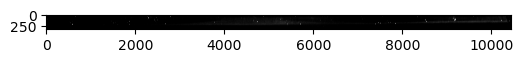

In [44]:
#fig, axs = plt.subplots(2, 1, figsize=(6, 12), gridspec_kw={'height_ratios': [1, 1]})
fig, axs = plt.subplots(1, 1, figsize=(6, 12))
#temp = temp[:100000]  # Limit to 10,000 emitters for rendering
px_size = 10.


'''
decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                        zextent=[-1200, 1200], colextent=[-1200, 1200], plot_axis=(0, 1),
                        contrast=15.25).render(temp, temp.xyz_nm[:, 2], ax=axs[0])
'''

decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=500,
                        zextent=[-1600, 1600], plot_axis=(0, 2)).render(temp, ax=axs)#[1])

(320, 10450)


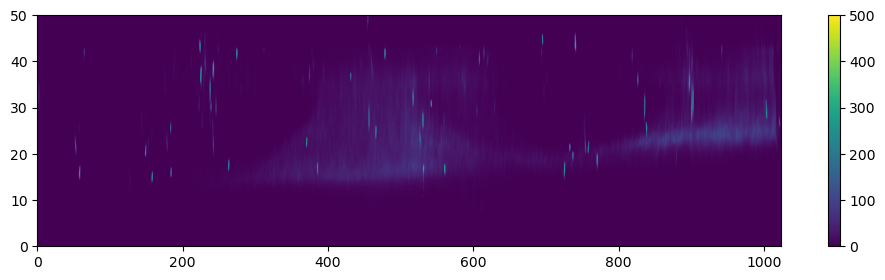

In [45]:
img = axs.images[0].get_array()

print(img.shape)


plt.figure(figsize=(12, 3))  # big figure to see better

plt.imshow(
    img,
    extent=[0, 1024, 0, 50],  # stretch vertically: map 12 rows into 200 units
    aspect='auto',             # allow non-square pixels
    interpolation='bilinear'   # smooth interpolation
)
plt.colorbar()
plt.show()


In [44]:
temp.xyz_px.shape

torch.Size([5002025, 3])

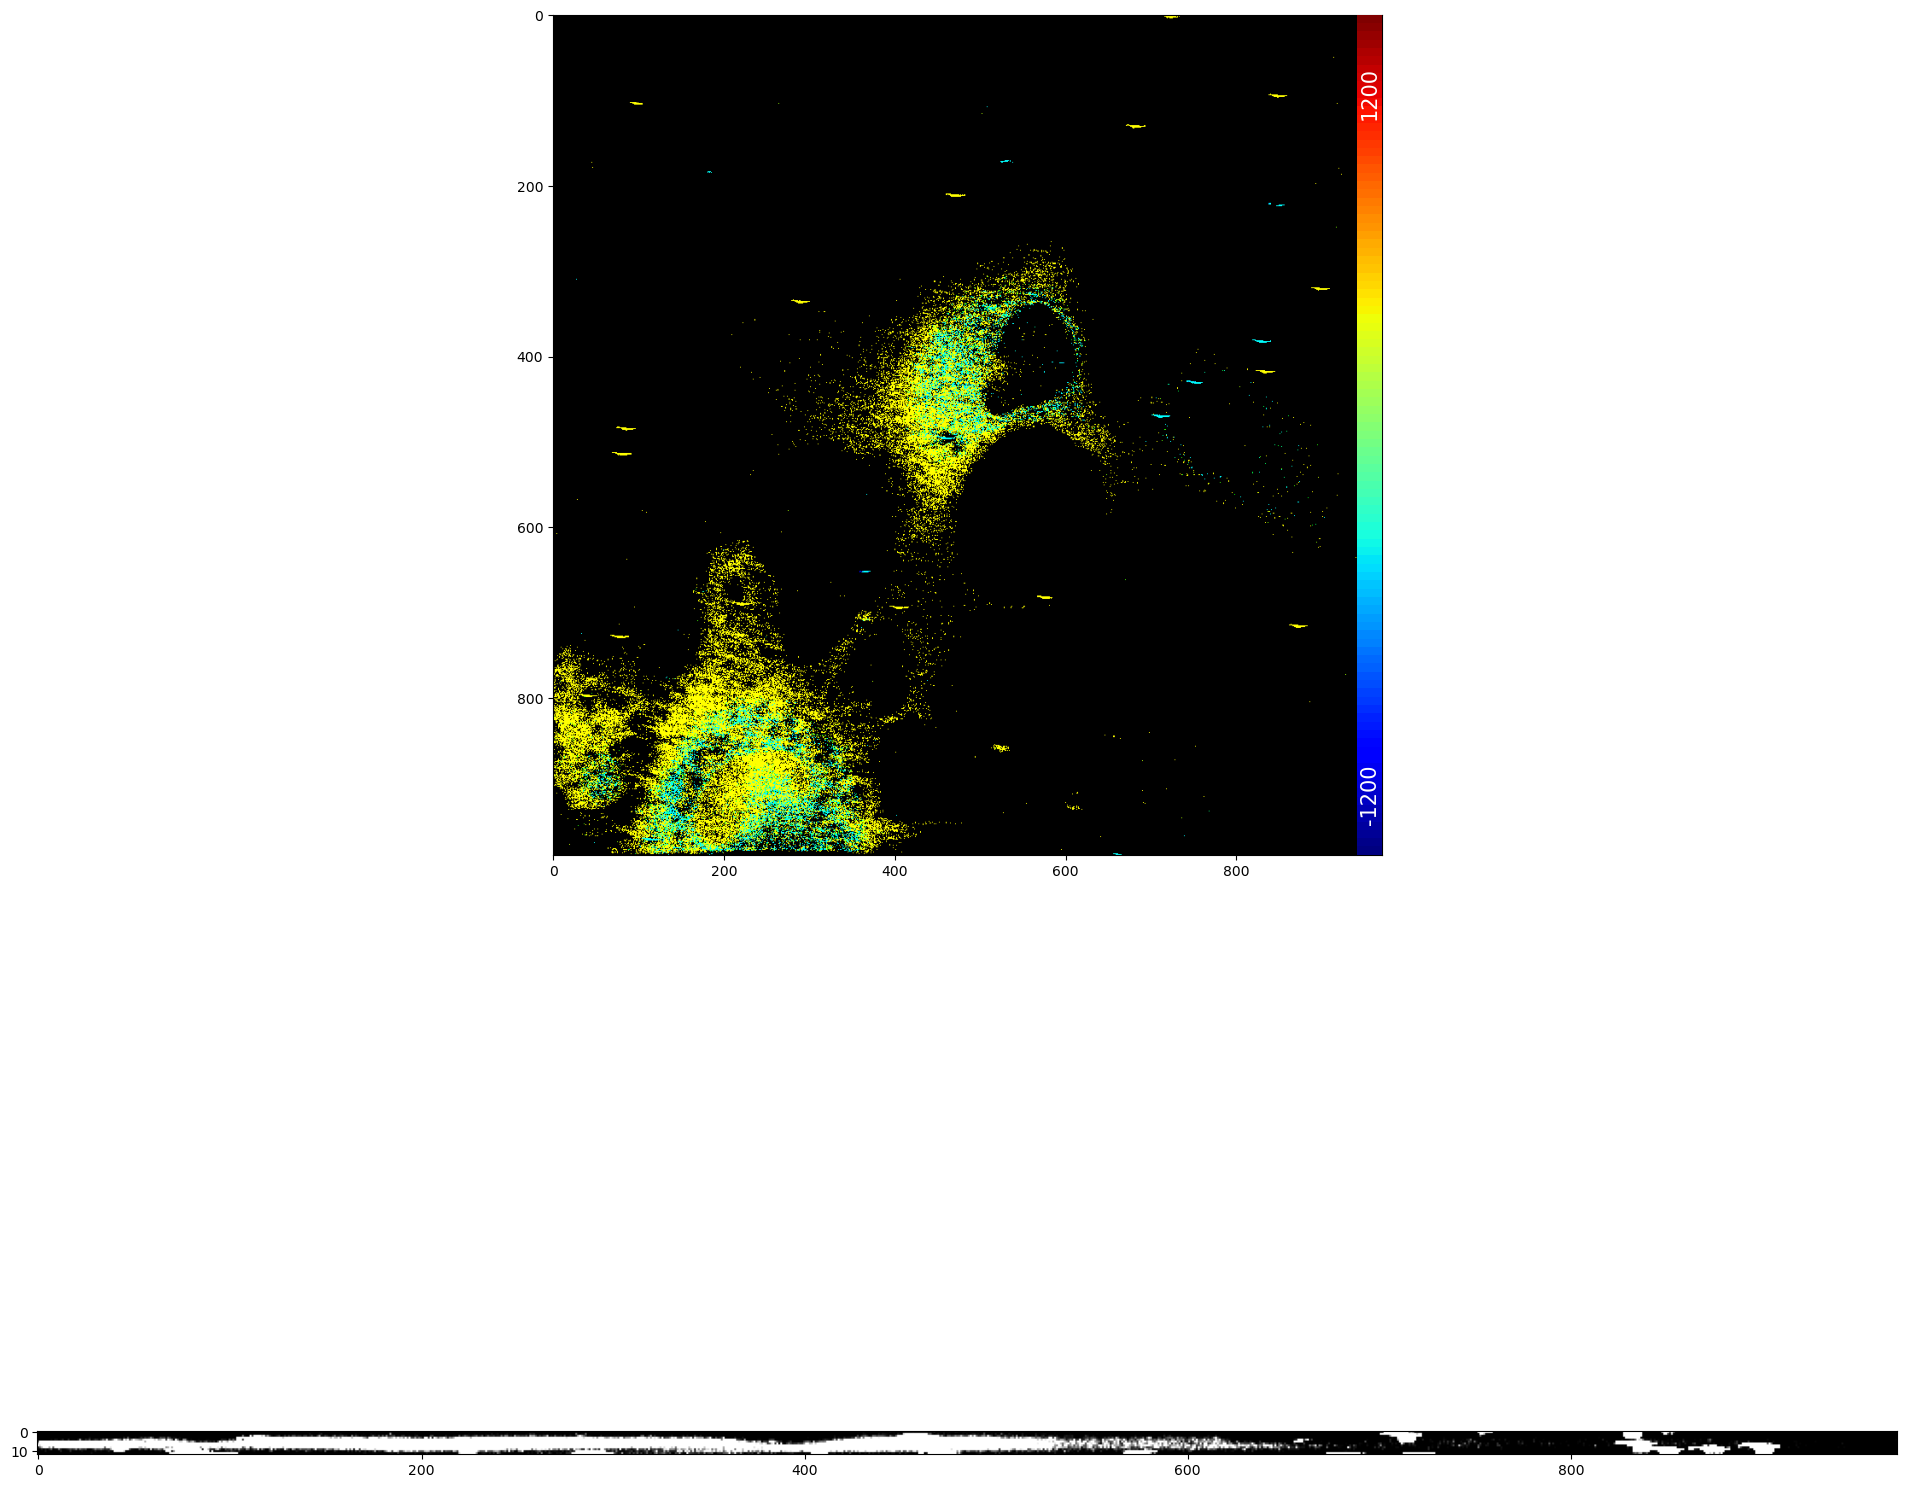

In [35]:
fig = render_emitters(emitters_filtered)

In [27]:

phot_lower_threshold = 2000

emitters_bead = emitters_filtered[
    emitters_filtered.phot >= phot_lower_threshold
    ]

emitters_bead = emitters_bead[
    (emitters_bead.xyz_px[:, 0]>= 0) & (emitters_bead.xyz_px[:, 0] <= 150) &
    (emitters_bead.xyz_px[:, 1]>= 0) & (emitters_bead.xyz_px[:, 1] <= 150) 
]

print(emitters_bead)




EmitterSet
::num emitters: 258957
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 267249
::spanned volume: [ 69.48067  116.947525 102.09232 ] - [  85.78819   124.072845 1207.0969  ]


In [28]:
from wip_util import get_np_points
bead_points = get_np_points(emitters_bead, 0, 10000000, True)

bead_points_ = bead_points[:, 0:3]

bead_points.shape, bead_points_.shape

((258957, 4), (258957, 3))

In [29]:

print(emitters.xyz_sig_nm[:,0].min(), emitters.xyz_sig_nm[:,0].max())
print(emitters.xyz_sig_nm[:,1].min(), emitters.xyz_sig_nm[:,1].max())
print(emitters.xyz_sig_nm[:,2].min(), emitters.xyz_sig_nm[:,2].max())

tensor(0.1419) tensor(390.1264)
tensor(0.1447) tensor(390.0947)
tensor(1.4612) tensor(4311.0645)


In [30]:
emitters_filtered.frame_ix.min(), emitters_filtered.frame_ix.max()

(tensor(0), tensor(267249))

(258957, 4)


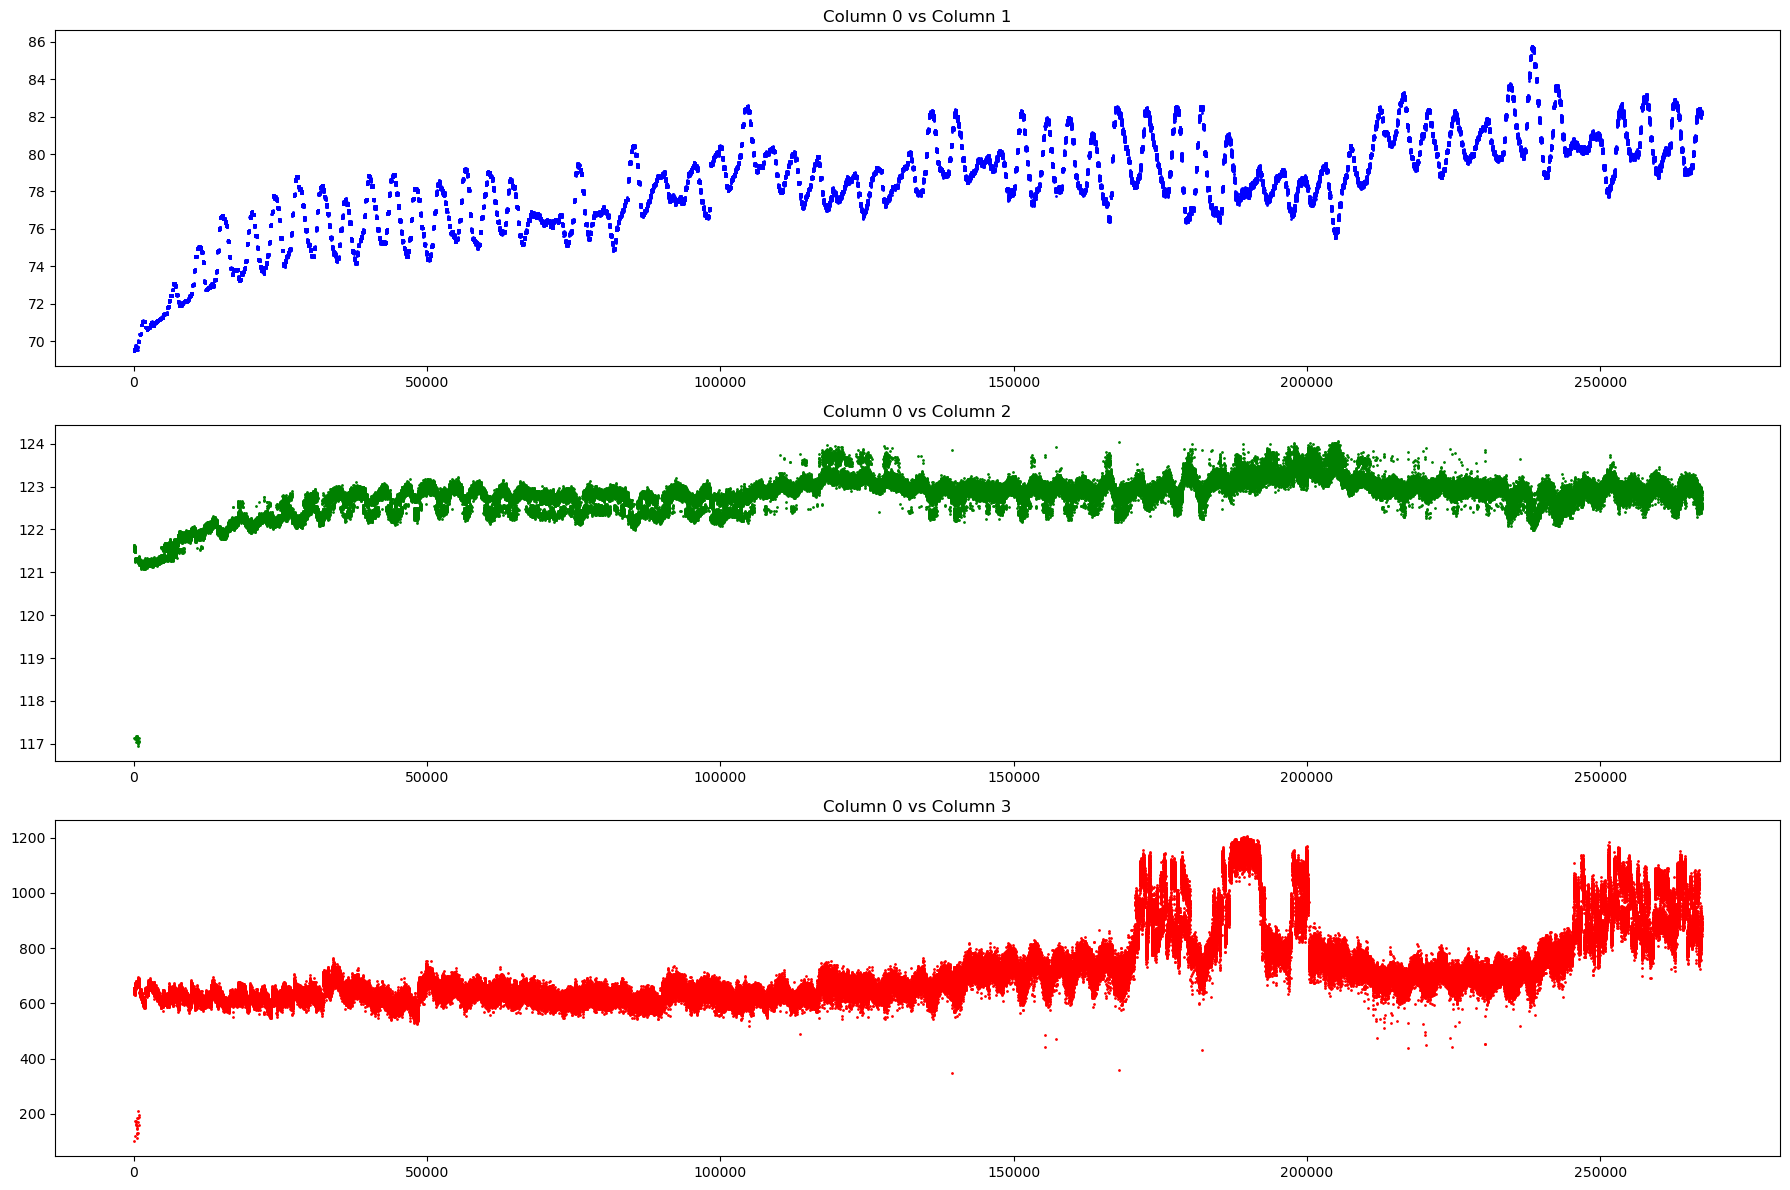

In [31]:
import matplotlib.pyplot as plt

# bead_points_ has shape (N, M) where columns are features
bead_points_=bead_points#[:20000,:]
print(bead_points_.shape)


fig, axes = plt.subplots(3, 1, figsize=(18, 12))  # 1 row, 3 columns

# Plot column 0 vs column 1
axes[0].scatter(bead_points_[:, 0], bead_points_[:, 1], s=1, color='blue')
axes[0].set_title('Column 0 vs Column 1')

# Plot column 0 vs column 2
axes[1].scatter(bead_points_[:, 0], bead_points_[:, 2], s=1, color='green')
axes[1].set_title('Column 0 vs Column 2')

# Plot column 0 vs column 3
axes[2].scatter(bead_points_[:, 0], bead_points_[:, 3], s=1, color='red')
axes[2].set_title('Column 0 vs Column 3')

plt.tight_layout()
plt.show()

## Registration Loop

In [17]:
print(start_iter, end_iter)

0 1069


In [32]:
import pandas as pd
drift_data = []

import numpy as np

emitters_corrected = emitters.clone()

bead_points_corrected = np.zeros_like(bead_points)

for i in tqdm(range(start_iter, end_iter+1)):
    start_frame = i * frames_per_iter
    end_frame = (i + 1) * frames_per_iter
    mask = bead_points[:,0] >= start_frame
    mask &= bead_points[:,0] < end_frame
    
    num_frames = mask.sum()

    

    avgx = bead_points[mask, 1].mean()
    avgy = bead_points[mask, 2].mean()
    avgz = bead_points[mask, 3].mean()
    
    
    if i == start_iter:
        startx = avgx
        starty = avgy
        startz = avgz
        driftx = 0.0
        drifty = 0.0
        driftz = 0.0
    elif num_frames == 0:
        driftx = 0.0
        drifty = 0.0
        driftz = 0.0
        print(f"Warning: No frames in iteration {i}, skipping drift correction.")
    else:
        driftx = avgx - startx
        drifty = avgy - starty
        driftz = avgz - startz

    bead_points_corrected[mask, 0] = bead_points[mask, 0]
    bead_points_corrected[mask, 1] = bead_points[mask, 1] - driftx
    bead_points_corrected[mask, 2] = bead_points[mask, 2] - drifty
    bead_points_corrected[mask, 3] = bead_points[mask, 3] - driftz

    entry = {
        'iter': i,
        'num_frames': num_frames,
        'x_drift': driftx,
        'y_drift': drifty,
        'z_drift': driftz}

    mask = emitters_corrected.frame_ix >= start_frame
    mask &= emitters_corrected.frame_ix < end_frame
    emitters_corrected.xyz_px[mask, 0] -= driftx
    emitters_corrected.xyz_px[mask, 1] -= drifty
    emitters_corrected.xyz_px[mask, 2] -= driftz    

    drift_data.append(entry)

print(len(drift_data), drift_data[100])

100%|█████████▉| 1069/1070 [08:06<00:00,  2.22it/s]C:\Users\bnort\AppData\Local\Temp\ipykernel_35616\2643892605.py:20: RuntimeWarning: Mean of empty slice.
  avgx = bead_points[mask, 1].mean()
c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\bnort\AppData\Local\Temp\ipykernel_35616\2643892605.py:21: RuntimeWarning: Mean of empty slice.
  avgy = bead_points[mask, 2].mean()
C:\Users\bnort\AppData\Local\Temp\ipykernel_35616\2643892605.py:22: RuntimeWarning: Mean of empty slice.
  avgz = bead_points[mask, 3].mean()


100%|██████████| 1070/1070 [08:06<00:00,  2.20it/s]

1070 {'iter': 100, 'num_frames': 250, 'x_drift': 5.968123340606695, 'y_drift': 0.9010923474629777, 'z_drift': -32.0444493471781}


In [33]:
print(emitters_corrected.xyz_sig_nm[:,0].min(), emitters_corrected.xyz_sig_nm[:,0].max())
print(emitters_corrected.xyz_sig_nm[:,1].min(), emitters_corrected.xyz_sig_nm[:,1].max())
print(emitters_corrected.xyz_sig_nm[:,2].min(), emitters_corrected.xyz_sig_nm[:,2].max())


out_corrected_h5 = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}_corrected.h5')

emitters_corrected.save(out_corrected_h5)


tensor(0.1419) tensor(390.1264)
tensor(0.1447) tensor(390.0947)
tensor(1.4612) tensor(4311.0645)


In [34]:
print(emitters_corrected)
sigma_x_high_threshold = 40
sigma_y_high_threshold = 40
sigma_z_high_threshold = 80
prob_threshold = 0.85
phot_lower_threshold = 3000
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitters_corrected_filtered = emitters_corrected[
    (emitters_corrected.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters_corrected.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters_corrected.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters_corrected.prob >= prob_threshold)
    #* (emitters_corrected.phot >= phot_lower_threshold)
    
    ]

print(emitters_corrected_filtered)



EmitterSet
::num emitters: 270211344
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 267249
::spanned volume: [  -16.57991      -2.8597689 -1786.9832   ] - [ 799.54364  801.48193 1440.6428 ]
0,1 0 500
EmitterSet
::num emitters: 29794279
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 267249
::spanned volume: [  -15.62777      -2.8079848 -1784.4111   ] - [ 799.41364  800.9758  1398.7009 ]


<AxesSubplot:>

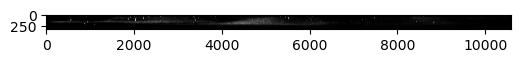

In [48]:
#fig, axs = plt.subplots(2, 1, figsize=(6, 12), gridspec_kw={'height_ratios': [1, 1]})
fig, axs = plt.subplots(1, 1, figsize=(6, 12))
#temp = temp[:100000]  # Limit to 10,000 emitters for rendering
px_size = 10.


'''
decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                        zextent=[-1200, 1200], colextent=[-1200, 1200], plot_axis=(0, 1),
                        contrast=15.25).render(temp, temp.xyz_nm[:, 2], ax=axs[0])
'''

decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=200,
                        zextent=[-1600, 1600], plot_axis=(0, 2)).render(emitters_corrected_filtered, ax=axs)#[1])

(320, 10596)


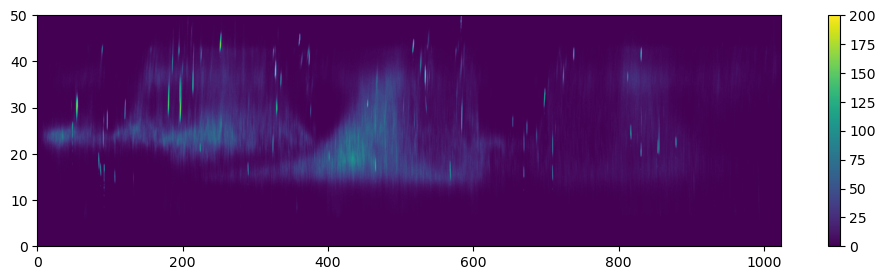

In [49]:
img = axs.images[0].get_array()

print(img.shape)


plt.figure(figsize=(12, 3))  # big figure to see better

plt.imshow(
    img,
    extent=[0, 1024, 0, 50],  # stretch vertically: map 12 rows into 200 units
    aspect='auto',             # allow non-square pixels
    interpolation='bilinear'   # smooth interpolation
)
plt.colorbar()
plt.show()


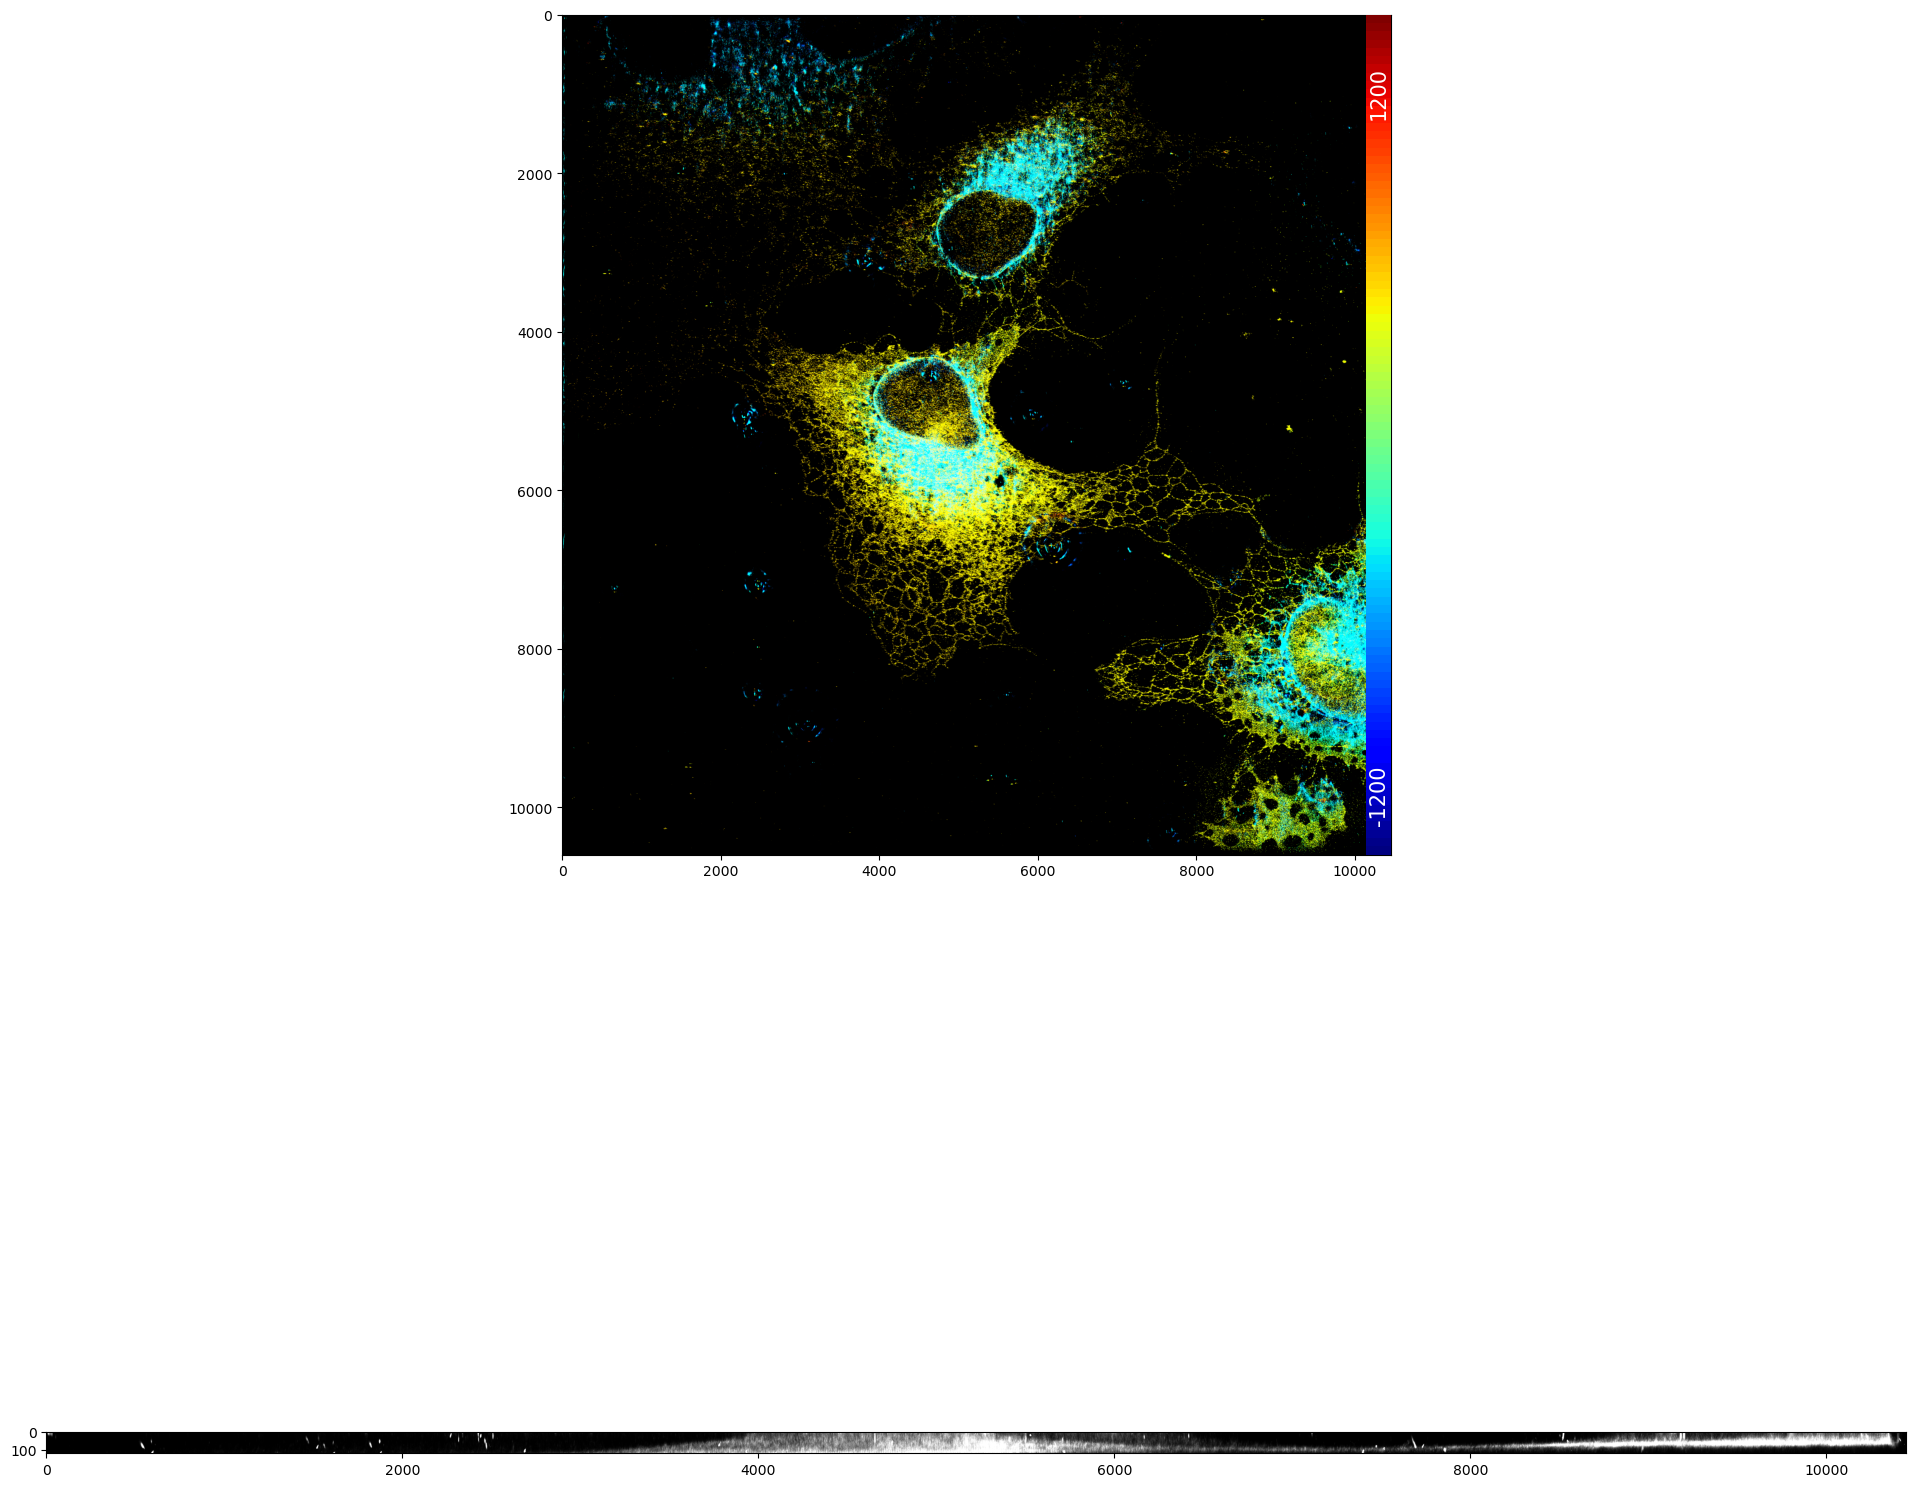

In [39]:
temp = emitters_corrected_filtered.clone()
temp.xyz_px = temp.xyz_px[:, [1,0,2]]  # Swap X and Y for rendering
temp.xyz_px[:,1] = 800 - temp.xyz_px[:,1]  # Invert Y for rendering

fig = render_emitters(temp)

fig.savefig(os.path.join(fig_path, rf'rendered_decode_fig_2400.png'), dpi=300, bbox_inches='tight')

In [29]:
emitters_corrected_filtered.xyz_sig_weighted_tot_nm.min(), emitters_corrected_filtered.xyz_sig_weighted_tot_nm.max()

(tensor(1.9344), tensor(69.5752))

C:\Users\bnort\AppData\Local\Temp\ipykernel_23344\2996410802.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


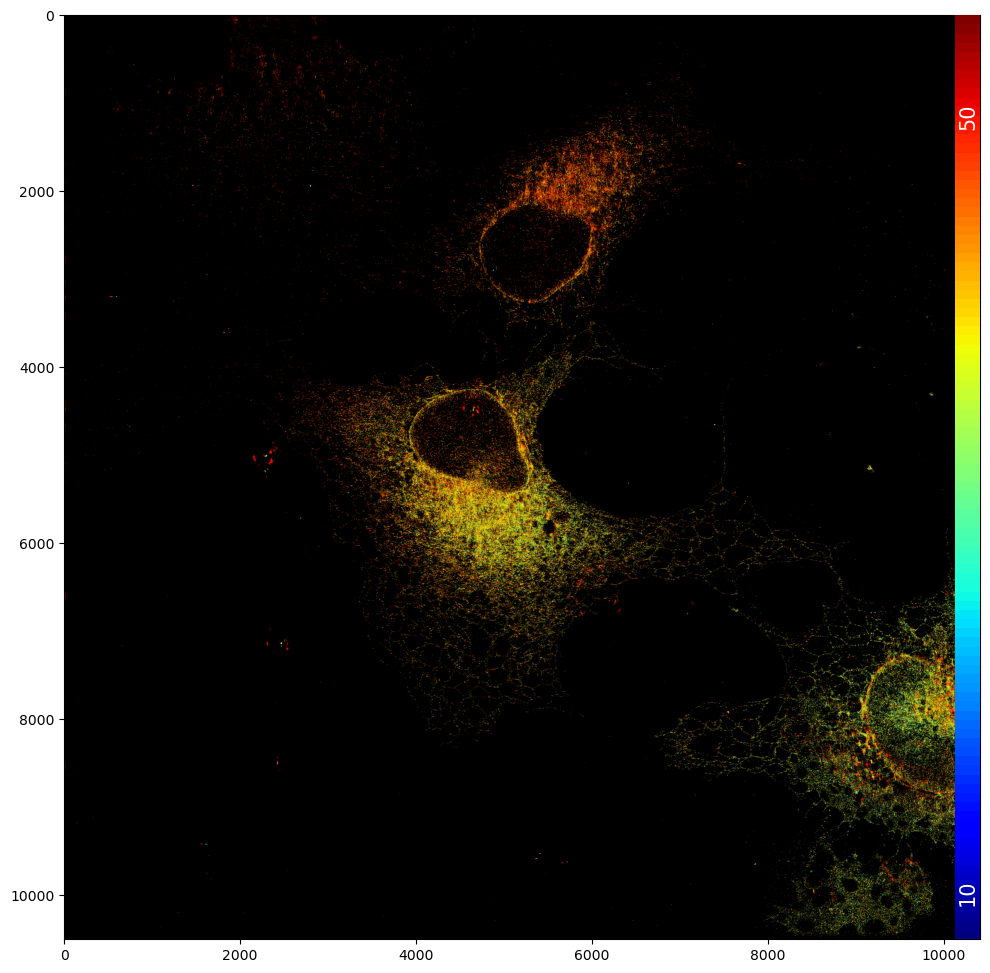

In [38]:
fig, axs = plt.subplots(1, 1, figsize=(24, 12))

px_size = 10.

decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=1,
                        zextent=[-1200, 1200], colextent=[10, 50], plot_axis=(0, 1),
                        contrast=1.25).render(temp, temp.xyz_sig_weighted_tot_nm, ax=axs)

fig.show()

fig.savefig(os.path.join(fig_path, rf'rendered_decode_sig_weighted_tot_nm.png'), dpi=300, bbox_inches='tight')


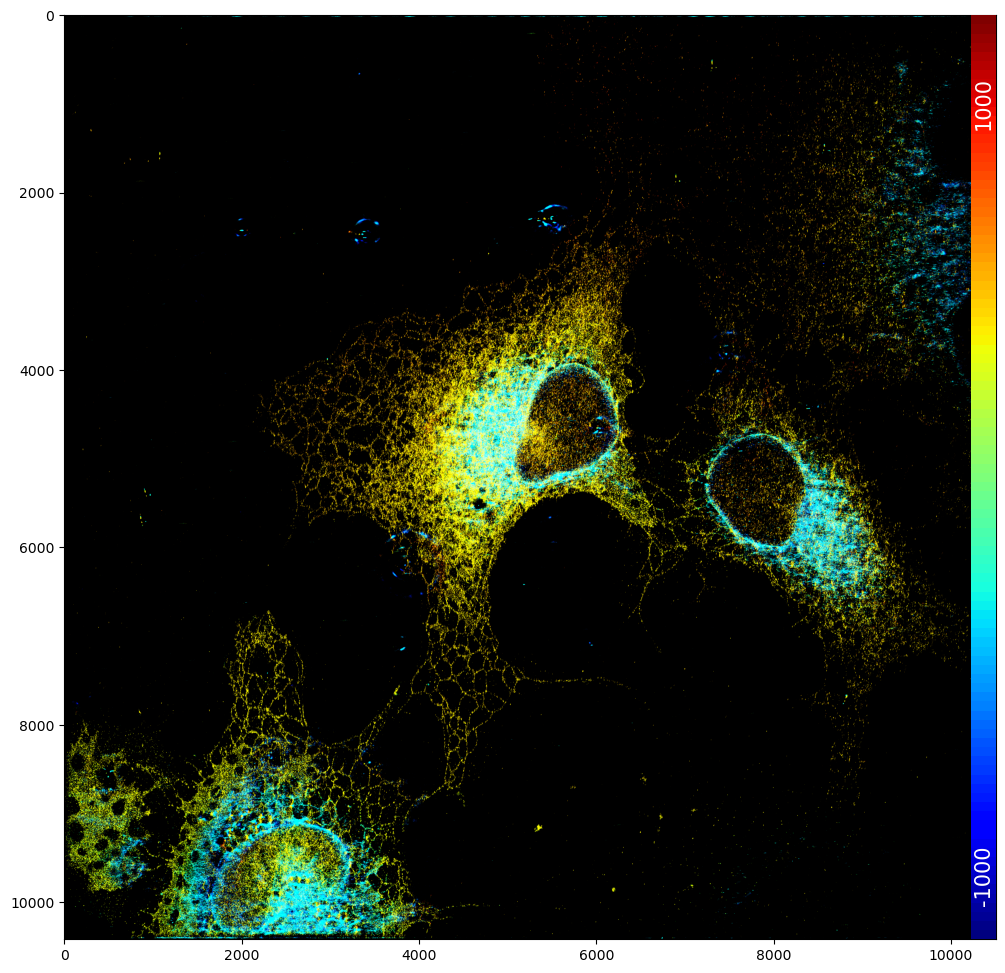

In [39]:
fig = render_emitters(emitters_corrected_filtered)

In [32]:
ax = fig.axes[0]
img = ax.images[0].get_array()

print(img.dtype, img.shape)

float64 (10414, 10505, 3)


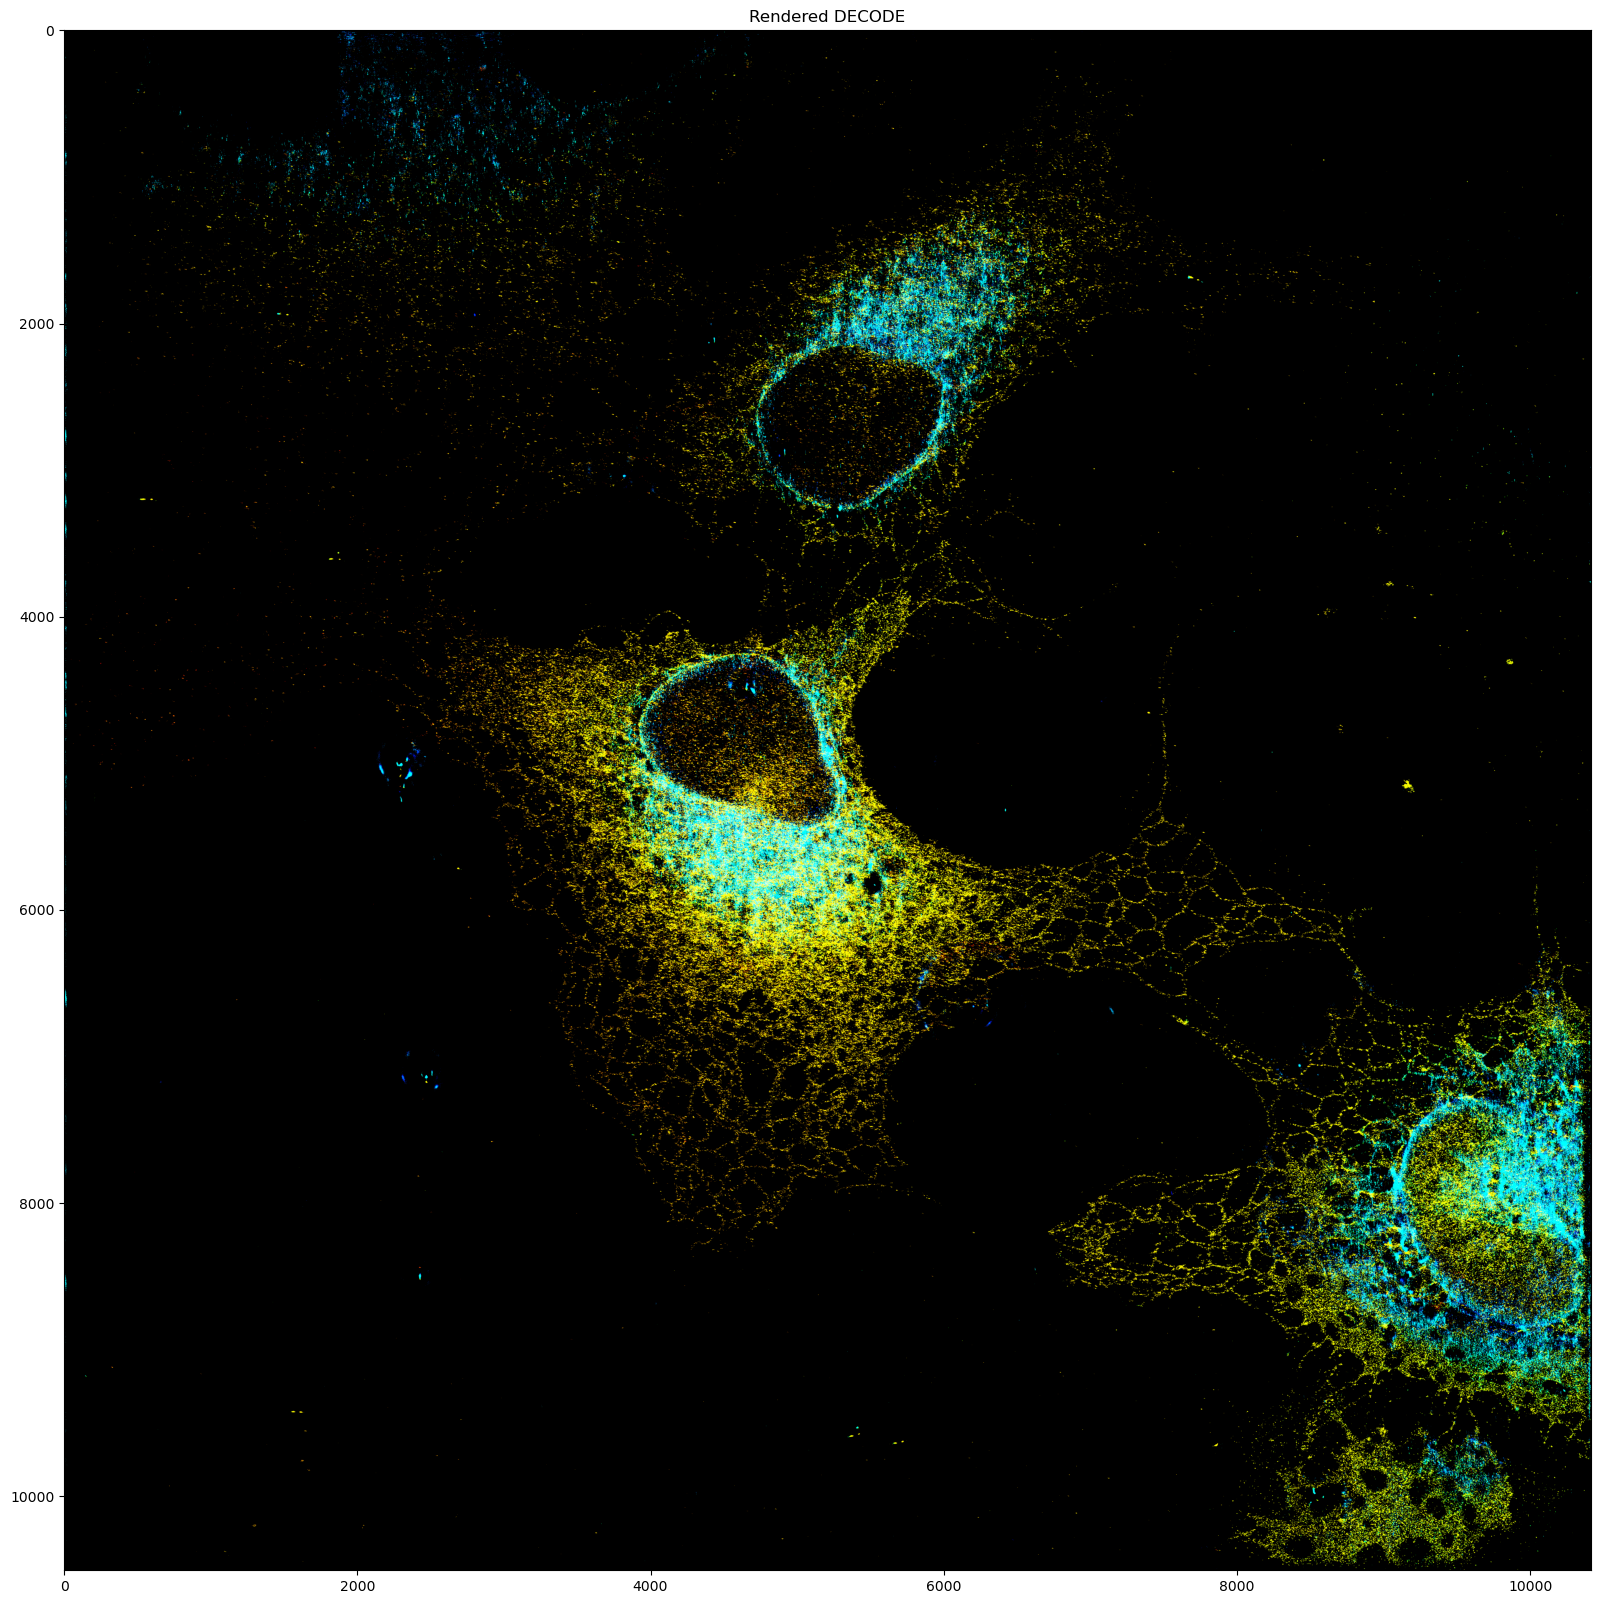

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imsave
imgt = np.transpose(img, (1, 0, 2))
imgt = imgt[::-1, :, :]
plt.figure(figsize=(20, 20))
plt.imshow(imgt, cmap='gray')
plt.title('Rendered DECODE')
#plt.savefig(os.path.join(fig_path, rf'rendered_decode.'), dpi=300, bbox_inches='tight')
imsave(os.path.join(fig_path, rf'rendered_decode.tif'), imgt)

In [23]:
imgt_cropped = imgt[5000:7000, 6000:9000, :]
plt.figure(figsize=(20, 20))
plt.imshow(imgt_cropped, cmap='gray')

NameError: name 'imgt' is not defined